# 1. Loading & prep

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import sys
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestRegressor


In [2]:
sys.path.append('..')  # points to the Modelling/ folder

from gam import SklearnGAM

sys.path.append('../..')  # points to the code folder
sys.path.append('/data/cleaning-scripts/')
from config import WINDOW_LENGTH, JANUARY_CLEANING_DATE, JULY_CLEANING_DATE, FOULING_PROXY_VAR_NAME_WITH_UNIT, SPEED_VARIABLE, WEATHER_FEATURES, NON_WEATHER_FEATURES, CANDIDATE_FEATURES

In [3]:
notebook_dir = os.getcwd()
notebook_parent_dir = os.path.dirname(notebook_dir)
notebook_parent_parent_dir = os.path.dirname(notebook_parent_dir)
engineered_data_path = os.path.join(notebook_parent_parent_dir, 'data', 'engineered', f'engineered_features_{WINDOW_LENGTH}.csv')

In [4]:
df = pd.read_csv(engineered_data_path)
df["window_start"] = pd.to_datetime(df["window_start"], format='ISO8601', utc=True)

In [5]:
df.columns

Index(['seg_id', 'window_start', 'Vessel Hull Over Ground Speed (knots)',
       'Vessel Hull Through Water Longitudinal Speed (knots)',
       'Vessel External Conditions Wind Relative Speed (knots)',
       'Vessel External Conditions Wind Relative Angle (degrees)',
       'Vessel Hull Heading True Angle (degrees)',
       'Vessel Hull Heading Turn Rate (deg/min)',
       'Main Engine Turbocharger Rotational Speed (rpm)',
       'Main Engine Scavenging Air Pressure (bar)',
       'Main Engine Fuel Load % (%)', 'Main Engine Rotational Speed (rpm)',
       'Vessel Propeller Shaft Torque (N*m)',
       'Vessel Propeller Shaft Mechanical Power (KW)',
       'Main Engine Fuel Oil Inlet Mass Flow (kg/hr)',
       'Vessel Propeller Shaft Mechanical Energy (KWh)',
       'Vessel Propeller Shaft Thrust Force (KN)',
       'Vessel Propeller Shaft Rotational Speed (rpm)',
       'Vessel Propeller Shaft Revolutions (cumulative) (revs)',
       'Sea Temperature Dropout', 'Calculated Shaft Power',

# 2. Correlations / VIFs

## 2.1. Correlations

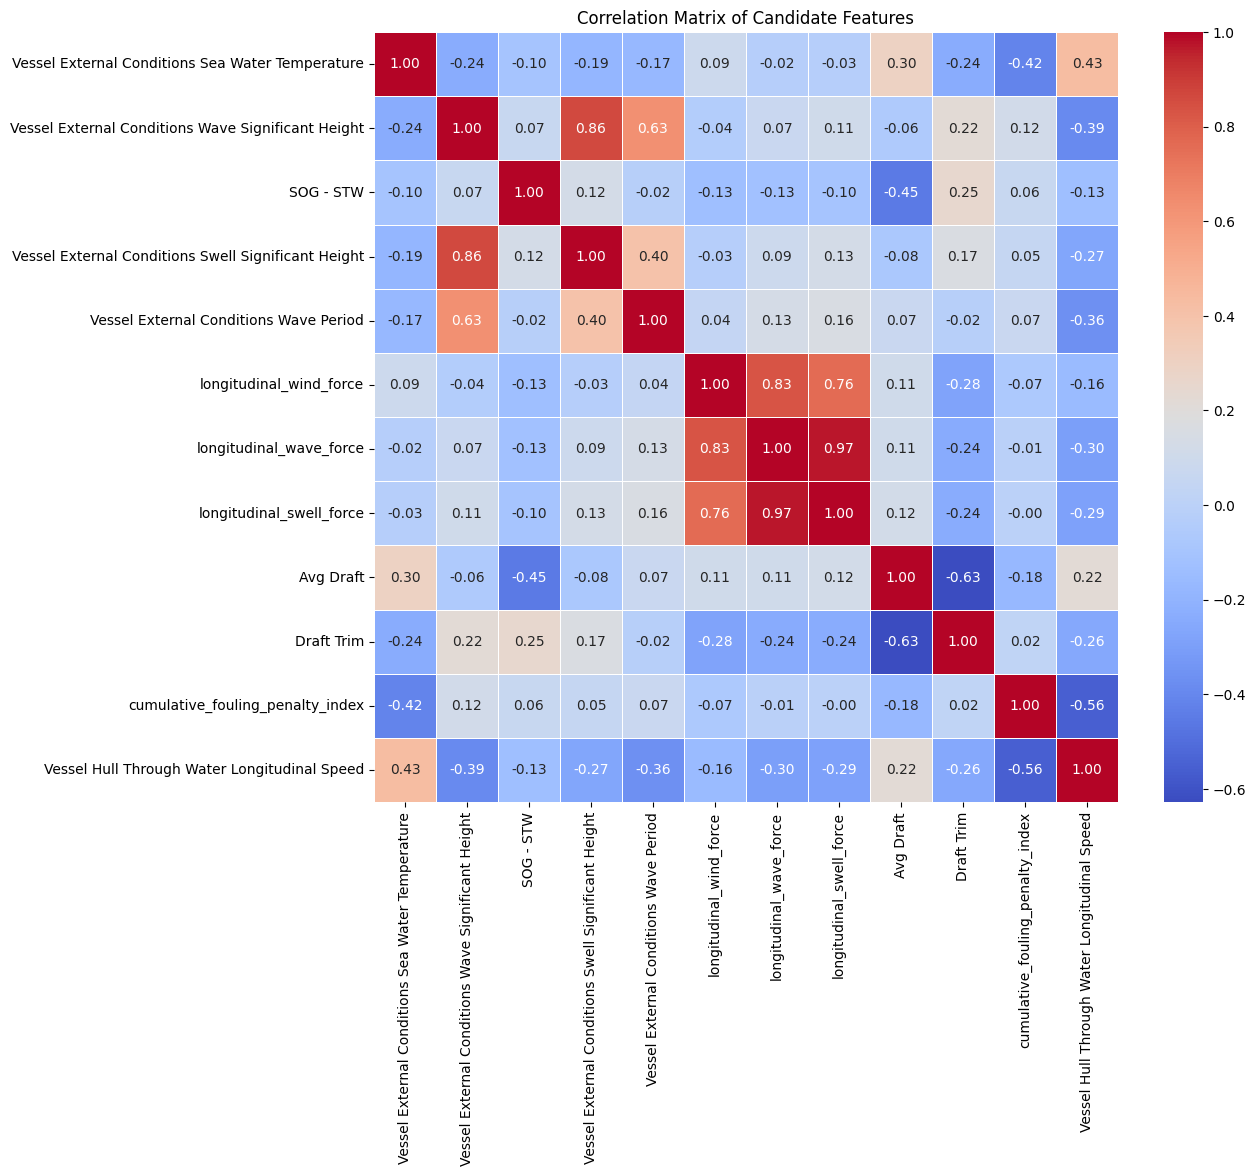

In [6]:
# make a correlation matrix between all the candidate features. Before plotting, remove everything inside parenthesis from the column names for better readability
correlation_df = df[CANDIDATE_FEATURES].copy()
correlation_df.columns = [col.split(' (')[0] for col in correlation_df.columns]
correlation_matrix = correlation_df.corr()

# plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Candidate Features')
plt.show()

## 2.2. VIFs

In [7]:
# Based on the candidate feautures, compute all the VIF scores and sort them from highest to lowest. Print it for all the features in a readable format.
def compute_vif(df: pd.DataFrame, candidate_features: list) -> pd.DataFrame:
    """
    Compute VIF for all candidate features and return sorted DataFrame.
    Drops rows with any NaN in the candidate columns before computing.
    """
    X = df[candidate_features].dropna()
    
    vif_data = pd.DataFrame({
        "Feature": candidate_features,
        "VIF": [variance_inflation_factor(X.values, i) 
                for i in range(len(candidate_features))]
    })
    
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

# Usage
vif_results = compute_vif(df, CANDIDATE_FEATURES)
print(vif_results.to_string(index=False))

                                                          Feature       VIF
             Vessel Hull Through Water Longitudinal Speed (knots) 53.286122
 Vessel External Conditions Wave Significant Height (Provider MB) 53.054975
    Vessel External Conditions Sea Water Temperature (Provider S) 41.184100
                             longitudinal_wave_force (calculated) 33.742742
Vessel External Conditions Swell Significant Height (Provider MB) 27.874457
                            longitudinal_swell_force (calculated) 24.245426
                                           Avg Draft (Calculated) 23.231219
              Vessel External Conditions Wave Period (Provider S) 13.476260
                                          Draft Trim (Calculated)  5.008174
                             longitudinal_wind_force (calculated)  4.635794
                    cumulative_fouling_penalty_index (calculated)  2.815759
                                           SOG - STW (calculated)  1.881854


## 2.3. Corr and VIF-based selection

### 2.3.1. First removal

In [ ]:
vars_to_remove = [
    'Vessel External Conditions Wave Significant Height (Provider MB)',
    'Vessel External Conditions Sea Water Temperature (Provider S)',
    'Vessel External Conditions Swell Significant Height (Provider MB)',
]

second_it_candidate_features = [feature for feature in CANDIDATE_FEATURES if feature not in vars_to_remove] 

df = df[second_it_candidate_features]

### 2.3.2. Second check

In [ ]:
vif__second_it_results = compute_vif(df, second_it_candidate_features)
print(vif__second_it_results.to_string(index=False))

                                             Feature       VIF
                longitudinal_wave_force (calculated) 33.238832
Vessel Hull Through Water Longitudinal Speed (knots) 26.025704
               longitudinal_swell_force (calculated) 23.893665
                              Avg Draft (Calculated) 21.025573
 Vessel External Conditions Wave Period (Provider S)  6.683108
                longitudinal_wind_force (calculated)  4.494218
                             Draft Trim (Calculated)  4.171344
       cumulative_fouling_penalty_index (calculated)  2.727137
                              SOG - STW (calculated)  1.824213


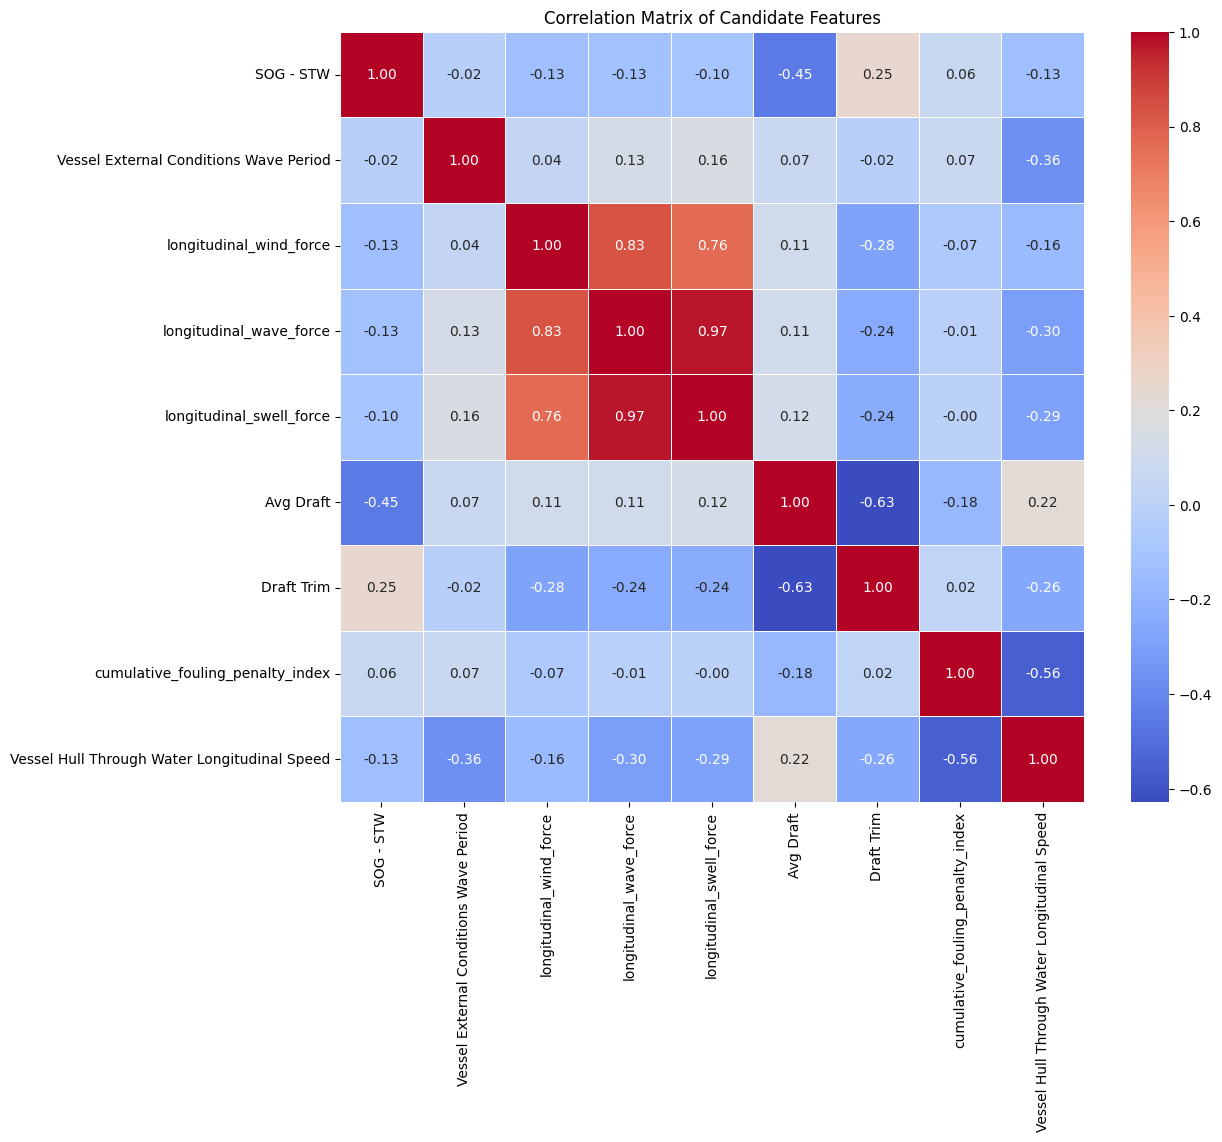

In [11]:
# make a correlation matrix between all the candidate features again. Before plotting, remove everything inside parenthesis from the column names for better readability
correlation_df = df[second_it_candidate_features].copy()
correlation_df.columns = [col.split(' (')[0] for col in correlation_df.columns]
correlation_matrix = correlation_df.corr()

# plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Candidate Features')
plt.show()

### 2.3.3. Second removal

In [16]:
vars_to_remove = [
    'longitudinal_swell_force (calculated)',
    'Draft Trim (Calculated)'
]

third_it_candidate_features = [feature for feature in second_it_candidate_features if feature not in vars_to_remove] 

df = df[third_it_candidate_features]

### 2.3.4. Third check

In [18]:
vif__third_it_results = compute_vif(df, third_it_candidate_features)
print(vif__third_it_results.to_string(index=False))

                                             Feature       VIF
Vessel Hull Through Water Longitudinal Speed (knots) 16.081948
                              Avg Draft (Calculated) 15.754253
 Vessel External Conditions Wave Period (Provider S)  6.301198
                longitudinal_wave_force (calculated)  3.739053
                longitudinal_wind_force (calculated)  3.717924
       cumulative_fouling_penalty_index (calculated)  2.676260
                              SOG - STW (calculated)  1.799653


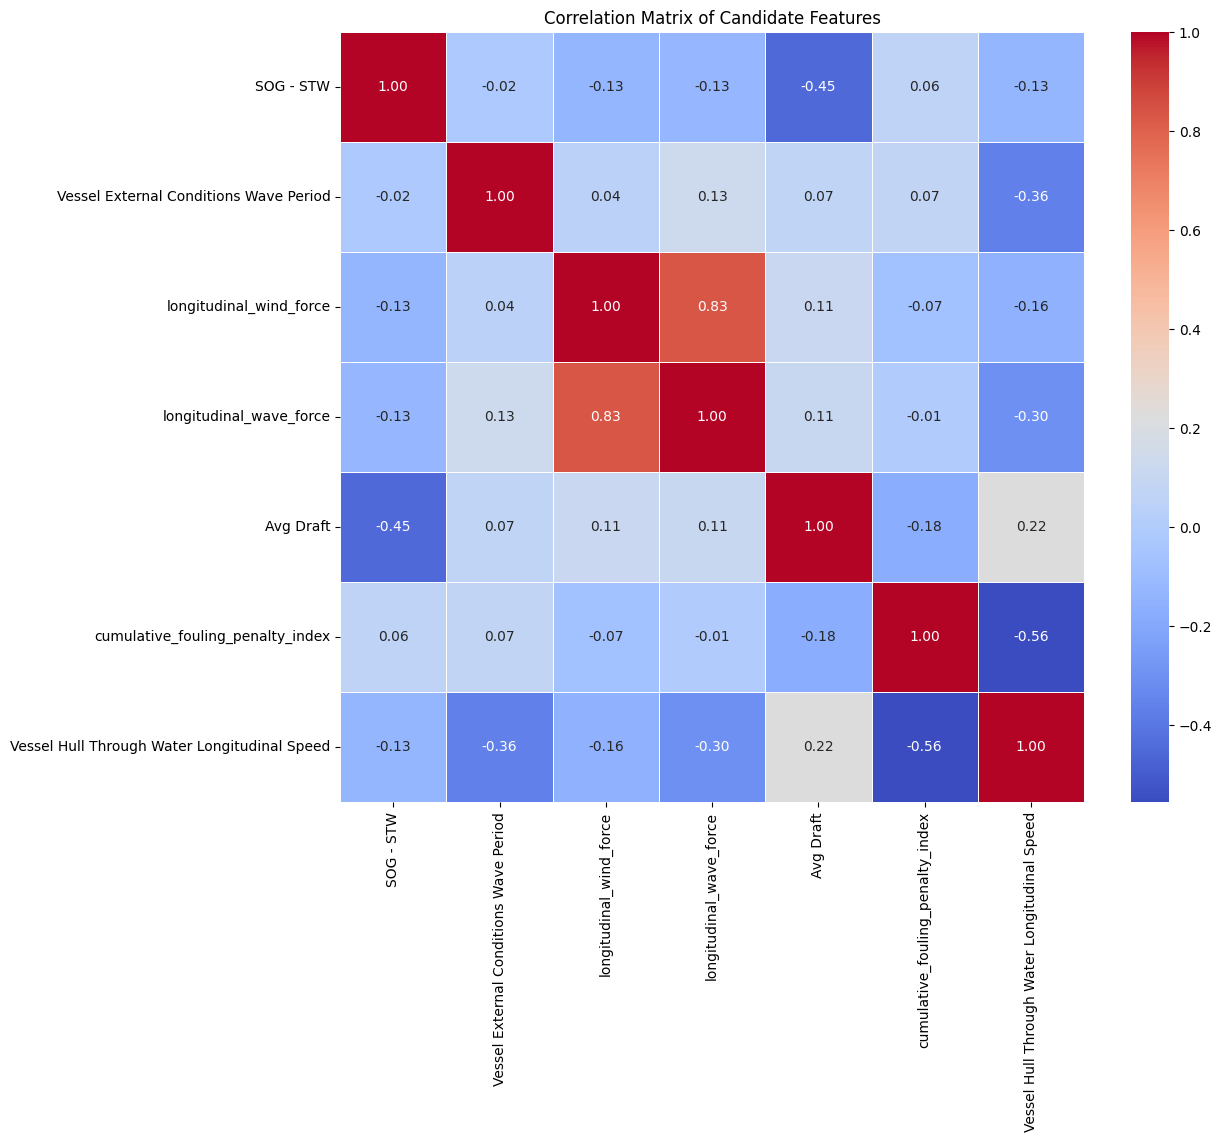

In [20]:
# make a correlation matrix between all the candidate features again. Before plotting, remove everything inside parenthesis from the column names for better readability
correlation_df = df[third_it_candidate_features].copy()
correlation_df.columns = [col.split(' (')[0] for col in correlation_df.columns]
correlation_matrix = correlation_df.corr()

# plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Candidate Features')
plt.show()

# 3. Feature Importance

Fits a SEPARATE random forest model and ranks features by importance

In [ ]:


# ── Define your target variable ────────────────────────────────────────────
# Replace with your actual target column, e.g. shaft power or fuel consumption
TARGET = "ME Shaft Power (kW)"   # ← adjust as needed

# ── Prepare data ────────────────────────────────────────────────────────────
model_df = df[thirditcandidatefeatures + [TARGET]].dropna()
X = model_df[thirditcandidatefeatures]
y = model_df[TARGET]

# ── Fit Random Forest ────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# ── Extract importances ──────────────────────────────────────────────────────
# Strip units in parentheses for cleaner labels
clean_names = [col.split("(")[0].strip() for col in thirditcandidatefeatures]

importance_df = (
    pd.DataFrame({"Feature": clean_names, "Importance": rf.feature_importances_})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print(importance_df.to_string(index=False))

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    importance_df["Feature"][::-1],   # highest at top
    importance_df["Importance"][::-1],
    color="steelblue",
    edgecolor="white",
)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)")
ax.set_title("Random Forest Feature Importance\n(7 Selected Features)")
ax.set_xlim(0, importance_df["Importance"].max() * 1.15)
plt.tight_layout()
plt.show()
